# Лабораторная работа №4

## Выполнил студент: Черкасов Александр Андреевич, ИВТб-2301

### Вариант 24

In [1]:
import numpy as np
import matplotlib.pyplot as plot
from IPython.display import display, Markdown
import pandas as pd
import scipy.integrate as integrate

def md(s: str) -> None:
    display(Markdown(s))

## 1. Вычисление определённого интеграла по формуле трапеций с заданной точностью

Задание:
Определённый интеграл от функции: $f(x) = \frac{1}{\sqrt{0.2x^2 + 1}}$
Пределы интегрирования: $[1.3; 2.5]$
Точность: $0.0001$

In [2]:
def f1(x):
    return 1 / np.sqrt(0.2 * x**2 + 1)

# Вторая производная f''(x), найденная аналитически
def f1_pp(x):
    return -0.2 * (0.2*x**2 + 1)**(-1.5) + 0.12 * x**2 * (0.2*x**2 + 1)**(-2.5)

a1, b1 = 1.3, 2.5
eps1 = 0.0001

# 1. Поиск максимума второй производной (M2) на отрезке
x_vals1 = np.linspace(a1, b1, 1000)
M2 = np.max(np.abs(f1_pp(x_vals1)))

# 2. Вычисляем количество отрезков n для обеспечения точности
n_trap = int(np.ceil(np.sqrt((b1 - a1)**3 * M2 / (12 * eps1))))
md(f"Максимум второй производной: $M_2 = {M2:.4f}$")
md(f"Требуемое число разбиений по формуле остаточного члена: **$n = {n_trap}$**")

def trapezoid_method(f, a, b, n):
    x = np.linspace(a, b, n+1)
    y = f(x)
    h = (b - a) / n
    return h * (0.5*y[0] + 0.5*y[-1] + np.sum(y[1:-1]))

res_trap = trapezoid_method(f1, a1, b1, n_trap)
md(f"Результат вычислений (Метод Трапеций): **{res_trap:.5f}**")

Максимум второй производной: $M_2 = 0.0395$

Требуемое число разбиений по формуле остаточного члена: **$n = 8$**

Результат вычислений (Метод Трапеций): **0.91600**

## 2. Вычисление интеграла по формуле Симпсона с оценкой Рунге

Задание:
Определённый интеграл от функции: $f(x) = \sqrt{x+1} \cdot \lg(x+3)$
Пределы интегрирования: $[0.15; 0.63]$
Точность: $0.0001$
Начальный шаг: $h \approx \sqrt[4]{\epsilon}$

In [3]:
def f2(x):
    return np.sqrt(x + 1) * np.log10(x + 3)

a2, b2 = 0.15, 0.63
eps2 = 0.0001

def simpson_method(f, a, b, n):
    x = np.linspace(a, b, n+1)
    y = f(x)
    h = (b - a) / n
    return (h / 3) * (y[0] + y[-1] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2]))

# Находим начальное число шагов
h_start = eps2**(1/4)
n_simp = int(np.ceil((b2 - a2) / h_start))
if n_simp % 2 != 0: 
    n_simp += 1 # n должно быть четным для Симпсона
if n_simp < 2:
    n_simp = 2

md(rf"Начальный шаг $h \approx {h_start:.4f}$, начальное число разбиений: $n = {n_simp}$")

# Итеративный пересчет с использованием правила Рунге
while True:
    I_h = simpson_method(f2, a2, b2, n_simp)
    I_h2 = simpson_method(f2, a2, b2, n_simp * 2)
    error = abs(I_h - I_h2) / 15
    if error <= eps2:
        break
    n_simp *= 2

res_simp = I_h2
md(f"Итоговое количество разбиений $n = {n_simp*2}$")
md(rf"Оценка погрешности по Рунге: $\Delta = {error:.7f} \le {eps2}$")
md(f"Результат вычислений (Метод Симпсона): **{res_simp:.5f}**")

Начальный шаг $h \approx 0.1000$, начальное число разбиений: $n = 6$

Итоговое количество разбиений $n = 12$

Оценка погрешности по Рунге: $\Delta = 0.0000000 \le 0.0001$

Результат вычислений (Метод Симпсона): **0.29997**

## 3. Вычисление интеграла по квадратурной формуле Гаусса

Задание:
Определённый интеграл от функции: $f(x) = \frac{x^2}{\sqrt{x+1.2}}$
Пределы интегрирования: $[1.6; 2.8]$

In [4]:
def f3(x):
    return x**2 / np.sqrt(x + 1.2)

a3, b3 = 1.6, 2.8

# Табличные значения из задания для n=4 (t_i и A_i)
t_4 = np.array([-0.86114, -0.33998, 0.33998, 0.86114])
A_4 = np.array([0.34785, 0.65215, 0.65215, 0.34785])

# Табличные значения из задания для n=7 (t_i и A_i)
t_7 = np.array([-0.949107912, -0.741531186, -0.405845151, 0, 0.405845151, 0.741531186, 0.949107912])
A_7 = np.array([0.129484966, 0.279705391, 0.381830051, 0.417959184, 0.381830051, 0.279705391, 0.129484966])

def gauss_quadrature(f, a, b, t_nodes, A_weights):
    # Преобразуем табличные узлы t_i из [-1, 1] в [a, b]
    x_nodes = 0.5 * (b - a) * t_nodes + 0.5 * (a + b)
    integral = 0.5 * (b - a) * np.sum(A_weights * f(x_nodes))
    return integral

res_gauss4 = gauss_quadrature(f3, a3, b3, t_4, A_4)
res_gauss7 = gauss_quadrature(f3, a3, b3, t_7, A_7)

md(f"Значение интеграла (Гаусс, $n=4$): **{res_gauss4:.6f}**")
md(f"Значение интеграла (Гаусс, $n=7$): **{res_gauss7:.6f}**")
md(f"Разница в расчетах (оценка улучшенной точности при 7 узлах): **{abs(res_gauss7 - res_gauss4):.8f}**")

Значение интеграла (Гаусс, $n=4$): **3.189780**

Значение интеграла (Гаусс, $n=7$): **3.189780**

Разница в расчетах (оценка улучшенной точности при 7 узлах): **0.00000015**

## 4. Проверка значений интегралов встроенными функциями SciPy

In [5]:
res_scipy1 = integrate.quad(f1, a1, b1)[0]
res_scipy2 = integrate.quad(f2, a2, b2)[0]
res_scipy3 = integrate.quad(f3, a3, b3)[0]

df_check = pd.DataFrame({
    'Задание': ['Трапеции (N1)', 'Симпсон (N2)', 'Гаусс (N3, n=7)'],
    'Наше вычисление': [res_trap, res_simp, res_gauss7],
    'Встроенная функция SciPy': [res_scipy1, res_scipy2, res_scipy3],
    'Абсолютная погрешность (абсолютная разница)': [abs(res_trap - res_scipy1), abs(res_simp - res_scipy2), abs(res_gauss7 - res_scipy3)]
})
display(df_check)

,Задание,Наше вычисление,Встроенная функция SciPy,Абсолютная погрешность (абсолютная разница)
0,Трапеции (N1),0.916004,0.915967,3.729353e-05
1,Симпсон (N2),0.299969,0.299969,1.878180e-10
2,"Гаусс (N3, n=7)",3.189780,3.189780,4.494138e-11


## 5. Решение обыкновенного дифференциального уравнения (ОДУ)

Задание: Разрешить на отрезке $0 \le x \le 1$ с шагом $h = 0.1$.

,x,y (h=0.1),y (h=0.05),Оценка погрешности (Рунге)
0,0.0,0.000000,0.000000,0.000000
1,0.1,0.005000,0.005011,0.000004
2,0.2,0.020174,0.020197,0.000008
3,0.3,0.045974,0.046011,0.000012
4,0.4,0.083159,0.083217,0.000019
5,0.5,0.132809,0.132897,0.000030
6,0.6,0.196333,0.196470,0.000046
7,0.7,0.275490,0.275700,0.000070
8,0.8,0.372392,0.372712,0.000107
9,0.9,0.489514,0.489991,0.000159


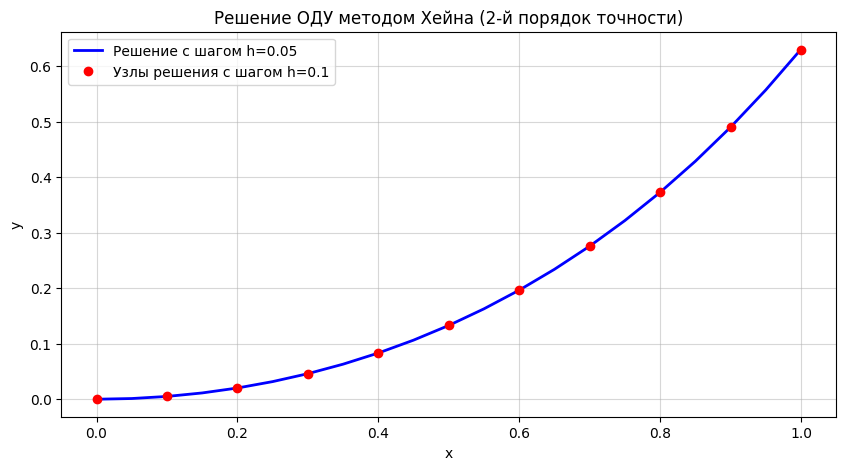

In [6]:
def ode_f(x, y):
    return y * np.sin(x) + x

def solve_heun(f, x0, y0, x_end, h_step):
    x_vals = np.arange(x0, x_end + h_step/2, h_step) # h_step/2 чтобы избежать ошибки округления в np.arange
    y_vals = np.zeros(len(x_vals))
    y_vals[0] = y0
    
    for i in range(len(x_vals) - 1):
        x_i = x_vals[i]
        y_i = y_vals[i]
        k1 = f(x_i, y_i)
        k2 = f(x_i + h_step, y_i + h_step * k1)
        y_vals[i+1] = y_i + (h_step / 2) * (k1 + k2)
    return x_vals, y_vals

x_0, y_0 = 0.0, 0.0
x_end_val = 1.0
h_1 = 0.1
h_2 = 0.05

# Решаем с шагом h=0.1
x_h1, y_h1 = solve_heun(ode_f, x_0, y_0, x_end_val, h_1)
# Решаем с шагом h=0.05
x_h2, y_h2 = solve_heun(ode_f, x_0, y_0, x_end_val, h_2)

# Для оценки погрешности по Рунге берем точки, общие для обоих решений (т.е. шаги h1)
# y_h2[::2] берет каждый второй элемент решения h=0.05
errors_runge = np.abs(y_h1 - y_h2[::2]) / 3

# Создаем таблицу
df_ode = pd.DataFrame({
    'x': x_h1,
    'y (h=0.1)': y_h1,
    'y (h=0.05)': y_h2[::2],
    'Оценка погрешности (Рунге)': errors_runge
})
display(df_ode)

# Графический вывод
plot.figure(figsize=(10, 5))
plot.plot(x_h2, y_h2, 'b-', label='Решение с шагом h=0.05', linewidth=2)
plot.plot(x_h1, y_h1, 'ro', label='Узлы решения с шагом h=0.1')
plot.grid(True, alpha=0.5)
plot.title("Решение ОДУ методом Хейна (2-й порядок точности)")
plot.xlabel("x")
plot.ylabel("y")
plot.legend()
plot.show()